# Đọc dữ liệu

In [47]:
# ==============================================================================
# CELL 1: IMPORT THƯ VIỆN VÀ ĐỌC DỮ LIỆU SẠCH (ĐÃ CHIA TRAIN/TEST TỪ TRƯỚC)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# 1. Đọc thẳng 2 file Train và Test đã lưu ở bước Clean
df_train_clean = pd.read_csv('data_output/1_data_cleaned_train.csv')
df_test_clean = pd.read_csv('data_output/1_data_cleaned_test.csv')

print("✅ Đã tải dữ liệu Train và Test thành công!")

# 2. Tách lại Biến độc lập (X) và Biến mục tiêu (y)
# LƯU Ý: Chỉnh sửa 'Khoảng giá' thành tên cột mục tiêu chính xác của bạn nếu cần
target_col = 'Khoảng giá' 

X_train = df_train_clean.drop(columns=[target_col])
y_train = df_train_clean[target_col]

X_test = df_test_clean.drop(columns=[target_col])
y_test = df_test_clean[target_col]

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")

✅ Đã tải dữ liệu Train và Test thành công!
Kích thước X_train: (4774, 18)
Kích thước X_test: (1197, 18)


# 1. Encode các biến catergorical: 'Pháp lý', 'Nội thất'

/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_60612/2486334255.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_60612/2486334255.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_60612/2486334255.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_60612/2486334255.py:49: UserWarning: set_ticklabels() should only be used with a fixed num

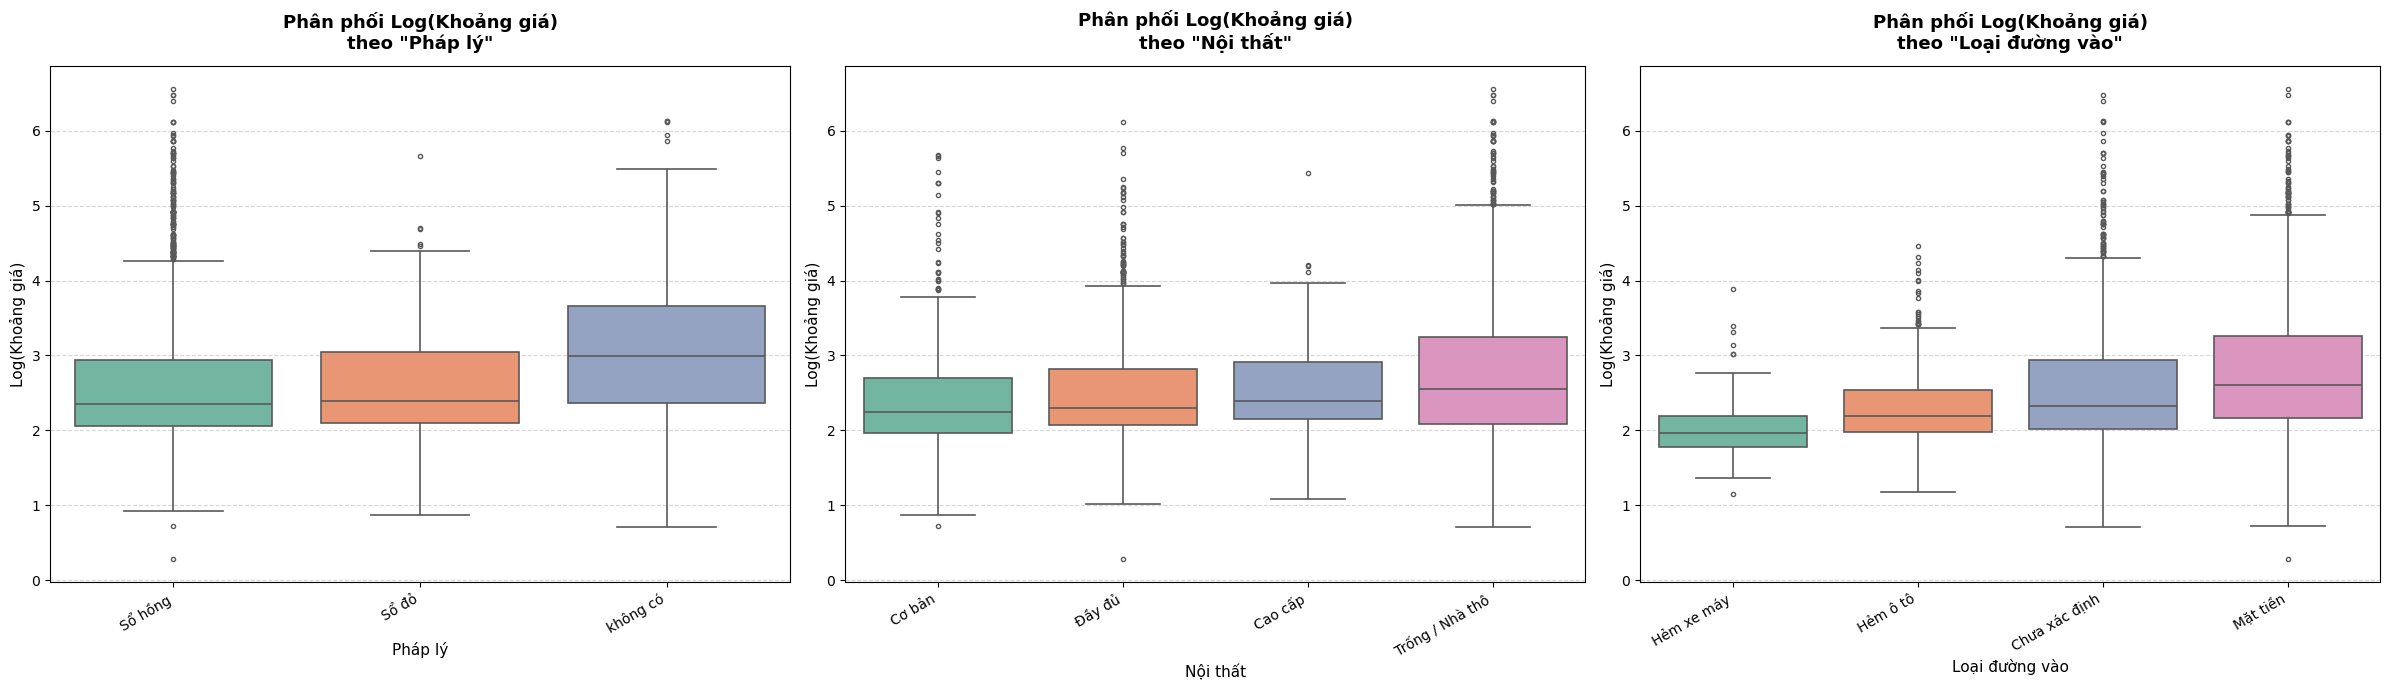

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: VẼ BOXPLOT KIỂM TRA TÍNH THỨ BẬC (DÙNG LOG SCALING)
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ghép X_train và y_train để phục vụ vẽ đồ thị đồng bộ
train_data = pd.concat([X_train, y_train], axis=1)

# Lấy tên cột mục tiêu (Khoảng giá)
target_col = y_train.name if isinstance(y_train, pd.Series) else y_train.columns[0]

# TẠO CỘT LOGARIT CỦA KHOẢNG GIÁ ĐỂ VẼ BIỂU ĐỒ TRỰC QUAN HƠN
log_target_col = f'Log_{target_col}'
train_data[log_target_col] = np.log1p(train_data[target_col])

# Danh sách các đặc trưng chữ cần phân tích
cat_cols = ['Pháp lý', 'Nội thất', 'Loại đường vào']

# 2. Khởi tạo khung hình với 1 hàng và 3 cột (side-by-side)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# 3. Vòng lặp tự động vẽ từng thuộc tính
for i, col in enumerate(cat_cols):
    if col in train_data.columns:
        # Sắp xếp các nhóm chữ theo trung vị (median) của giá (đã log) tăng dần
        group_order = train_data.groupby(col)[log_target_col].median().sort_values().index
        
        sns.boxplot(
            x=col, 
            y=log_target_col,  # <--- Dùng cột Log để vẽ thay vì cột gốc
            data=train_data, 
            ax=axes[i], 
            order=group_order,
            palette='Set2',
            fliersize=3,       # Thu nhỏ bớt các điểm ngoại lai cho đỡ rối
            linewidth=1.2      # Tăng độ đậm của viền hộp
        )
        
        # Tinh chỉnh tiêu đề và nhãn
        axes[i].set_title(f'Phân phối Log({target_col})\ntheo "{col}"', fontsize=13, fontweight='bold', pad=12)
        axes[i].set_xlabel(col, fontsize=11)
        axes[i].set_ylabel(f'Log({target_col})', fontsize=11)
        axes[i].grid(axis='y', linestyle='--', alpha=0.5)
        
        # Xoay chữ nhẹ góc 30 độ
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')

# 4. Cân đối khoảng cách giữa các biểu đồ và hiển thị
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: ORDINAL ENCODING (PHÁP LÝ & NỘI THẤT)
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# 1. Định nghĩa thứ tự cho từng cột (Từ thấp đến cao)
# Với Pháp lý: 'không có' (0) < 'Sổ đỏ' (1) < 'Sổ hồng' (2)
phap_ly_order = ['không có', 'Sổ đỏ', 'Sổ hồng']

# Với Nội thất: 'Trống / Nhà thô' (0) < 'Cơ bản' (1) < 'Đầy đủ' (2) < 'Cao cấp' (3)
noi_that_order = ['Trống / Nhà thô', 'Cơ bản', 'Đầy đủ', 'Cao cấp']

# 2. Khởi tạo bộ Ordinal Encoder
# - categories: Truyền danh sách các thứ tự đã định nghĩa ở trên (phải đúng thứ tự cột truyền vào)
# - handle_unknown='use_encoded_value' & unknown_value=-1: Nếu tập Test có nhãn lạ, gán bằng -1
orde = OrdinalEncoder(
    categories=[phap_ly_order, noi_that_order], 
    handle_unknown='use_encoded_value', 
    unknown_value=-1
)

# Các cột cần Ordinal Encoding
ord_cols = ['Pháp lý', 'Nội thất']

# 3. Học cấu trúc từ tập Train và biến đổi trực tiếp tập Train
# Khác với One-Hot sinh ra nhiều cột mới, Ordinal chỉ thay thế giá trị trên chính cột đó
X_train[ord_cols] = orde.fit_transform(X_train[ord_cols])

# 4. Chỉ biến đổi tập Test dựa trên tập luật đã học
X_test[ord_cols] = orde.transform(X_test[ord_cols])

print("✅ Đã áp dụng Ordinal Encoding thành công cho Pháp lý và Nội thất!")
print(f"Thứ tự Pháp lý đã mã hóa: {phap_ly_order} -> [0, 1, 2]")
print(f"Thứ tự Nội thất đã mã hóa: {noi_that_order} -> [0, 1, 2, 3]")

✅ Đã áp dụng One-Hot Encoding thành công cho Pháp lý và Nội thất!
Các cột mới được sinh ra: ['Pháp lý_Sổ đỏ', 'Pháp lý_không có', 'Nội thất_Cơ bản', 'Nội thất_Trống / Nhà thô', 'Nội thất_Đầy đủ']


# 2. Encode các biến từ địa chỉ.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: TARGET ENCODING VỚI SMOOTHING (CẤU HÌNH RIÊNG CHO TỪNG CẤP ĐỘ)
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd
from category_encoders import TargetEncoder

# -----------------------------------------------------------------------
# NHÓM 1: Cột 'Quận' (Dữ liệu lớn hơn -> Cần min_samples_leaf cao hơn)
# -----------------------------------------------------------------------
cols_quan = ['Quận']
te_quan = TargetEncoder(cols=cols_quan, smoothing=10.0, min_samples_leaf=50)

# Học và biến đổi trên tập Train/Test
X_train[cols_quan] = te_quan.fit_transform(X_train[cols_quan], y_train)
X_test[cols_quan] = te_quan.transform(X_test[cols_quan])


# -----------------------------------------------------------------------
# NHÓM 2: Cột 'Phường/Xã' & 'Đường' (Dữ liệu nhỏ, phân tán -> min_samples_leaf thấp hơn)
# -----------------------------------------------------------------------
cols_phuong_duong = ['Phường/Xã/Thị Trấn', 'Đường_Từ_Địa_Chỉ']
te_phuong_duong = TargetEncoder(cols=cols_phuong_duong, smoothing=10.0, min_samples_leaf=5)

# Học và biến đổi trên tập Train/Test
X_train[cols_phuong_duong] = te_phuong_duong.fit_transform(X_train[cols_phuong_duong], y_train)
X_test[cols_phuong_duong] = te_phuong_duong.transform(X_test[cols_phuong_duong])


print("✅ Đã áp dụng Target Encoding thành công!")
print("  - Cột 'Quận': min_samples_leaf = 50")
print("  - Cột 'Phường/Xã/Thị Trấn' & 'Đường_Từ_Địa_Chỉ': min_samples_leaf = 5")

# 2. Chuẩn hoá các thuộc tính dạng số.

Bài toán mà bộ dữ liệu này hướng tới là dự đoán giá nhà. Đó là dạng bài toán cần sử dụng các mô hình hồi quy. Các phương pháp chuẩn hoá sẽ hướng tới việc xây dựng bộ dữ liệu phù họp với các mô hình hồi quy tuyến tính có giả định.bộ dữ liệu là phân phối chuẩn.

Thống kê phân phối của các đặc trưng số học.

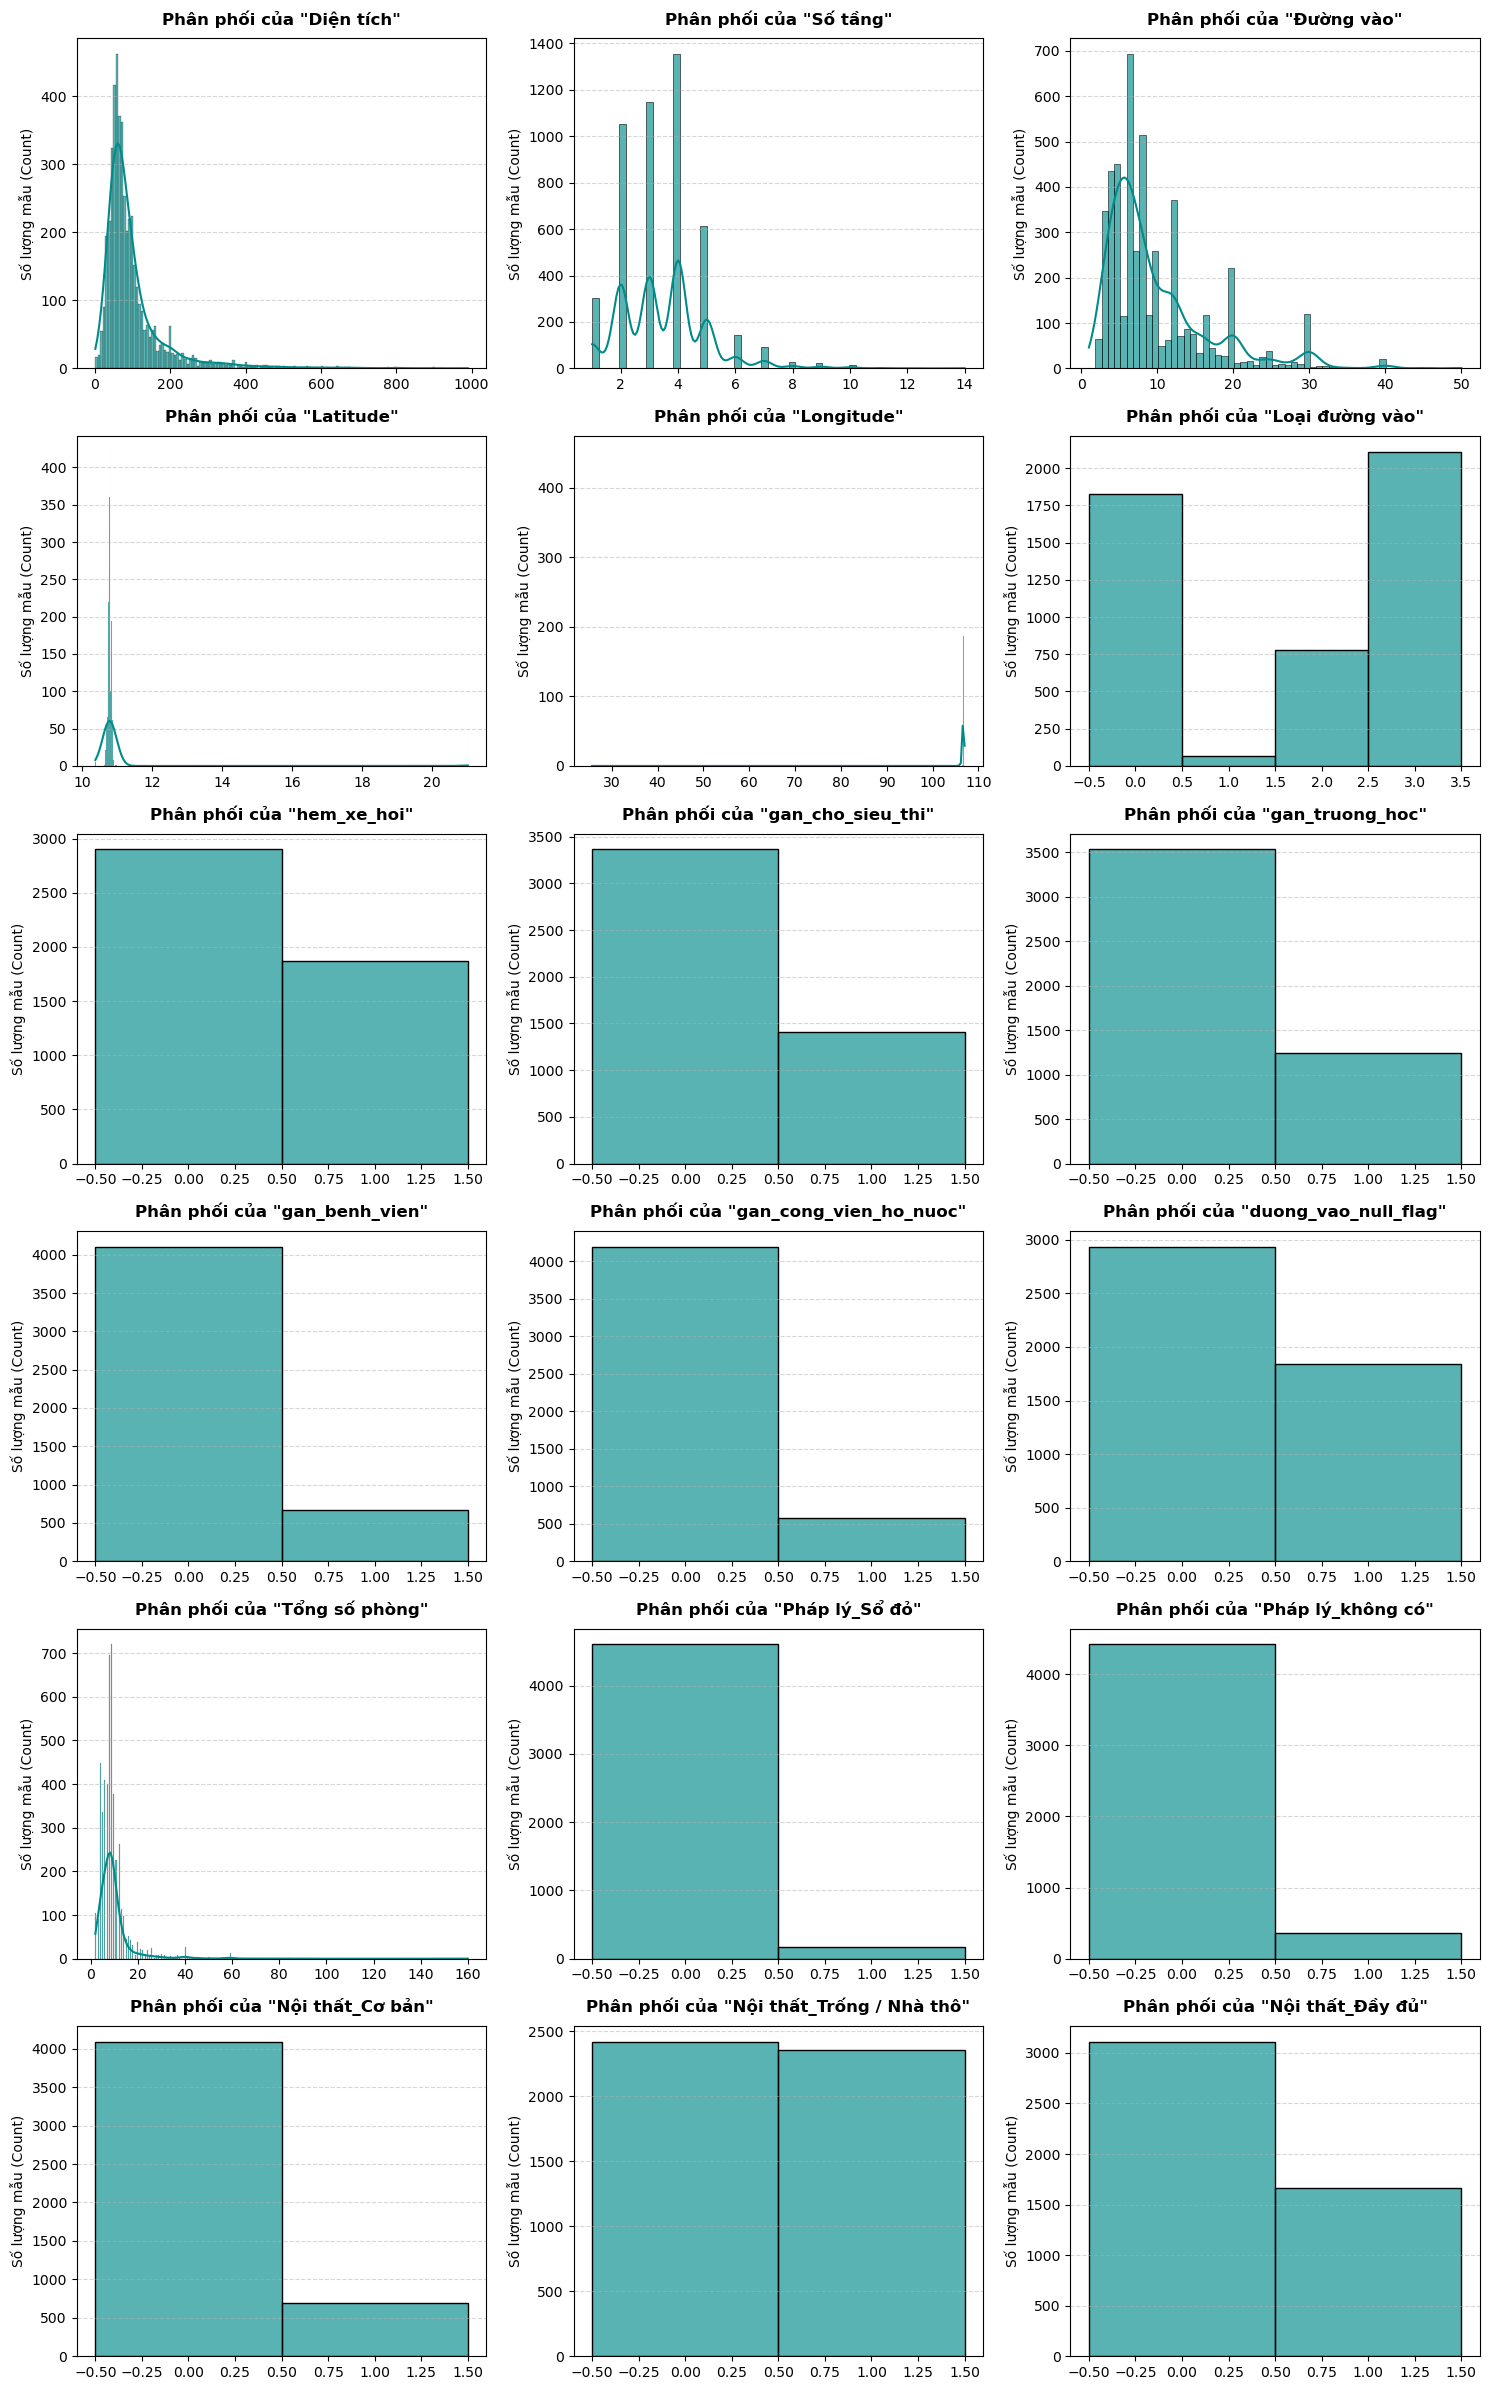

In [51]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: VẼ BIỂU ĐỒ PHÂN PHỐI CHỈ CHO CÁC ĐẶC TRƯNG SỐ HỌC TRONG X_TRAIN
# ═══════════════════════════════════════════════════════════════════════
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tự động lọc ra DÂN SỐ CÁC CỘT SỐ HỌC trong X_train
numeric_features = list(X_train.select_dtypes(include=[np.number]).columns)
num_features = len(numeric_features)

# 2. Tự động tính toán số hàng và số cột cho lưới đồ thị (Mặc định 3 biểu đồ mỗi hàng)
cols_per_row = 3
num_rows = math.ceil(num_features / cols_per_row)

# Khởi tạo khung hình tổng thể dựa trên số lượng đặc trưng số
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(cols_per_row * 5, num_rows * 4))

# Phẳng hóa mảng axes để dễ dàng duyệt qua bằng vòng lặp đơn
if num_features > 1:
    axes = axes.flatten()
else:
    axes = [axes] # Phòng trường hợp chỉ có đúng 1 cột số

# 3. Vòng lặp vẽ phân phối cho từng đặc trưng số
for i, col in enumerate(numeric_features):
    ax = axes[i]
    
    # Kiểm tra xem biến đó là biến liên tục hay biến nhị phân/rời rạc (One-Hot)
    # Nếu biến chỉ có từ 5 giá trị phân biệt trở xuống -> Coi là rời rạc
    is_discrete = X_train[col].nunique() <= 5
    
    sns.histplot(
        data=X_train,
        x=col,
        kde=not is_discrete,  # Chỉ vẽ đường cong mật độ KDE cho biến liên tục
        discrete=is_discrete, # Ép các cột nhị phân hiển thị tách biệt rõ ràng tại 0 và 1
        ax=ax,
        color='darkcyan',     # Đổi sang tông màu lục lam đậm trực quan
        edgecolor='black',
        alpha=0.65
    )
    
    # Tinh chỉnh giao diện cho từng ô đồ thị
    ax.set_title(f'Phân phối của "{col}"', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('')  
    ax.set_ylabel('Số lượng mẫu (Count)', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Ẩn đi các ô đồ thị còn thừa (nếu lưới chia không vừa vặn)
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

# 5. Tự động tối ưu khoảng cách và hiển thị
plt.tight_layout()
plt.show()

## 2.1 Chuẩn hoá 'Diện tích', 'Đường vào' và 'Tổng số phòng'

Phân phối của 2 thuộc tính này lệch phải nặng. Sử dụng logarit để kéo dữ liệu về phân phối chuẩn sau đó dùng StandardScaler hoặc RobustScaler

### Phương pháp 1: Sử dụng logarit để kéo dữ liệu về phân phối chuẩn sau đó dùng StandardScaler

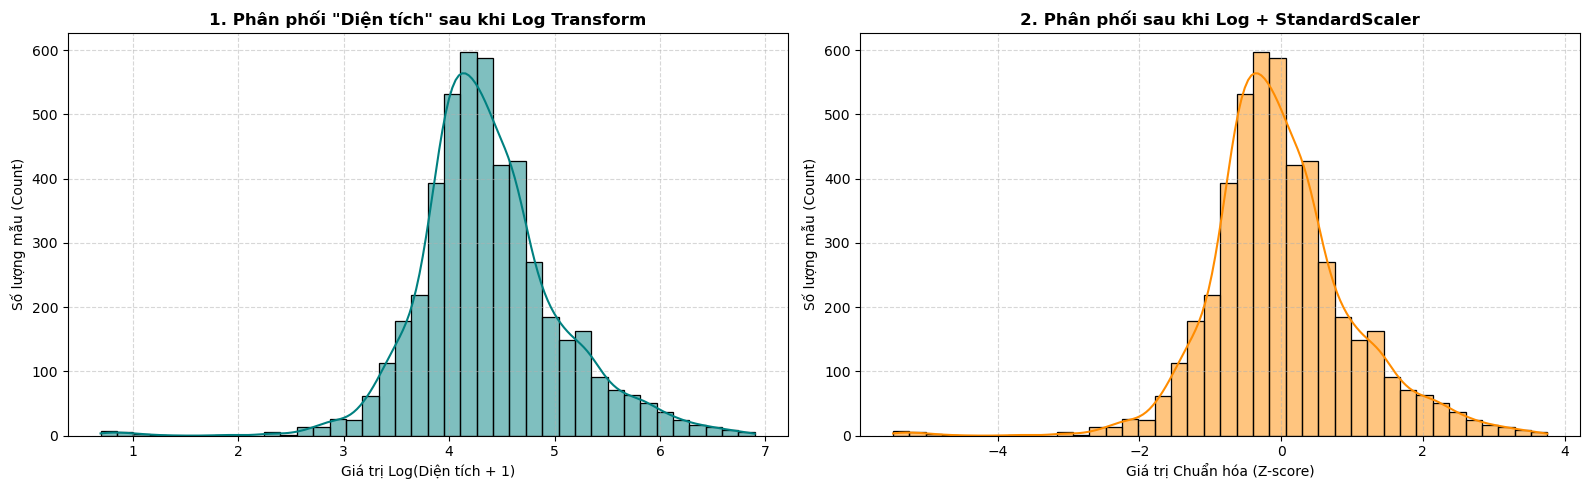

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Trích xuất một bản sao của cột Diện tích để thử nghiệm
dien_tich_test = X_train['Diện tích'].copy()

# 2. Áp dụng Logarithm (Dùng log1p để an toàn nếu có giá trị bằng 0)
dien_tich_log = np.log1p(dien_tich_test)

# 3. Áp dụng StandardScaler lên dữ liệu đã Log
# (Cần reshape(-1, 1) vì StandardScaler yêu cầu mảng 2 chiều)
scaler_test = StandardScaler()
dien_tich_scaled = scaler_test.fit_transform(dien_tich_log.values.reshape(-1, 1)).flatten()

# 4. Vẽ biểu đồ so sánh kết quả từng bước xử lý
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị bước 1: Sau khi Log
sns.histplot(dien_tich_log, kde=True, ax=axes[0], color='teal', bins=40)
axes[0].set_title('1. Phân phối "Diện tích" sau khi Log Transform', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá trị Log(Diện tích + 1)')
axes[0].set_ylabel('Số lượng mẫu (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Đồ thị bước 2: Sau khi Log + Scale
sns.histplot(dien_tich_scaled, kde=True, ax=axes[1], color='darkorange', bins=40)
axes[1].set_title('2. Phân phối sau khi Log + StandardScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Chuẩn hóa (Z-score)')
axes[1].set_ylabel('Số lượng mẫu (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Phương pháp 2: Sử dung phương pháp RobustScaler

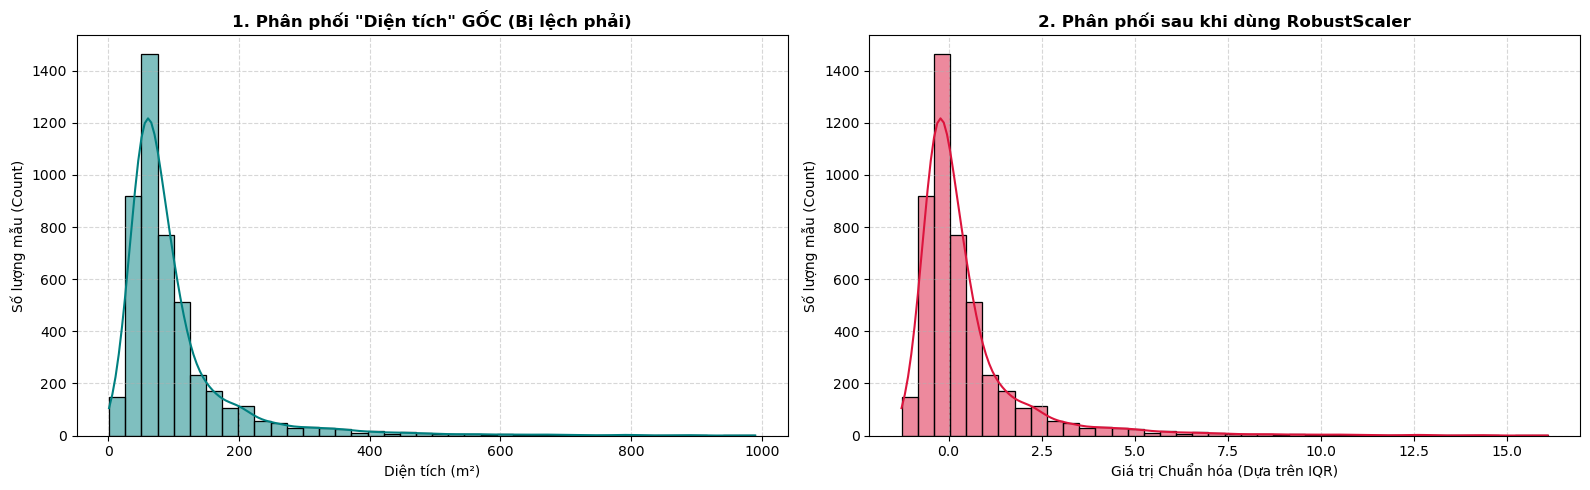

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# 1. Trích xuất một bản sao của cột Diện tích để thử nghiệm
dien_tich_test = X_train['Diện tích'].copy()

# 2. Áp dụng RobustScaler
scaler_robust_test = RobustScaler()
dien_tich_robust = scaler_robust_test.fit_transform(dien_tich_test.values.reshape(-1, 1)).flatten()

# 3. Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị bước 1: Phân phối gốc
sns.histplot(dien_tich_test, kde=True, ax=axes[0], color='teal', bins=40)
axes[0].set_title('1. Phân phối "Diện tích" GỐC (Bị lệch phải)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Diện tích (m²)')
axes[0].set_ylabel('Số lượng mẫu (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Đồ thị bước 2: Sau khi dùng RobustScaler
sns.histplot(dien_tich_robust, kde=True, ax=axes[1], color='crimson', bins=40)
axes[1].set_title('2. Phân phối sau khi dùng RobustScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Chuẩn hóa (Dựa trên IQR)')
axes[1].set_ylabel('Số lượng mẫu (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Phân phối vẫn bị lệch phải sau khi sử dụng phép biến đổi RobustScaler. Nếu dùng Sử dụng logarit để kéo dữ liệu về phân phối chuẩn sau đó dùng StandardScaler thì sẽ đưa được phân phối về dạng có lợi cho việc huấn luyện mô hình hồi quy.

### Lựa chọn phương pháp.

🚀 Đang áp dụng Phương pháp 1: Logarithm + StandardScaler...
✅ Hoàn tất áp dụng Log + StandardScaler cho cả X_train và X_test!


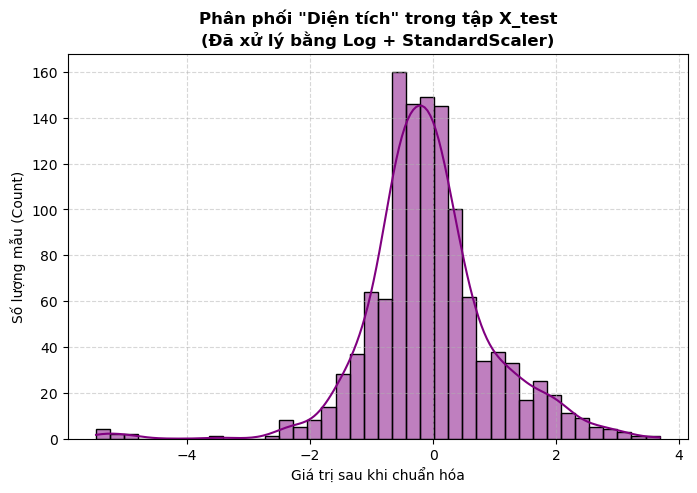

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler

# =================================================================
# ⚙️ BẢNG ĐIỀU KHIỂN: HÃY CHỌN PHƯƠNG PHÁP BẠN MUỐN ÁP DỤNG
# Điền 1 -> Sử dụng (Log1p + StandardScaler)
# Điền 2 -> Sử dụng (RobustScaler)
# =================================================================
PHUONG_PHAP = 1  # <-- Sửa số này thành 1 hoặc 2 tùy ý bạn

if PHUONG_PHAP == 1:
    print("🚀 Đang áp dụng Phương pháp 1: Logarithm + StandardScaler...")
    # Xử lý Log cho cả Train và Test
    X_train['Diện tích'] = np.log1p(X_train['Diện tích'])
    X_test['Diện tích'] = np.log1p(X_test['Diện tích'])
    
    # Chuẩn hóa StandardScaler
    scaler = StandardScaler()
    X_train['Diện tích'] = scaler.fit_transform(X_train[['Diện tích']])
    X_test['Diện tích'] = scaler.transform(X_test[['Diện tích']])
    method_name = "Log + StandardScaler"

elif PHUONG_PHAP == 2:
    print("🚀 Đang áp dụng Phương pháp 2: RobustScaler...")
    # Chuẩn hóa RobustScaler
    scaler = RobustScaler()
    X_train['Diện tích'] = scaler.fit_transform(X_train[['Diện tích']])
    X_test['Diện tích'] = scaler.transform(X_test[['Diện tích']])
    method_name = "RobustScaler"

else:
    print("❌ Lựa chọn không hợp lệ. Vui lòng chọn 1 hoặc 2.")

# =================================================================
# 📊 VẼ BIỂU ĐỒ KIỂM TRA TRÊN TẬP TEST
# =================================================================
if PHUONG_PHAP in [1, 2]:
    print(f"✅ Hoàn tất áp dụng {method_name} cho cả X_train và X_test!")
    
    plt.figure(figsize=(8, 5))
    sns.histplot(X_test['Diện tích'], kde=True, color='purple', bins=40)
    plt.title(f'Phân phối "Diện tích" trong tập X_test\n(Đã xử lý bằng {method_name})', fontsize=12, fontweight='bold')
    plt.xlabel('Giá trị sau khi chuẩn hóa')
    plt.ylabel('Số lượng mẫu (Count)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

## 2.2 Xử lý cột 'Đường vào'

### Phương pháp 1: Sử dụng logarit để kéo dữ liệu về phân phối chuẩn sau đó dùng StandardScaler

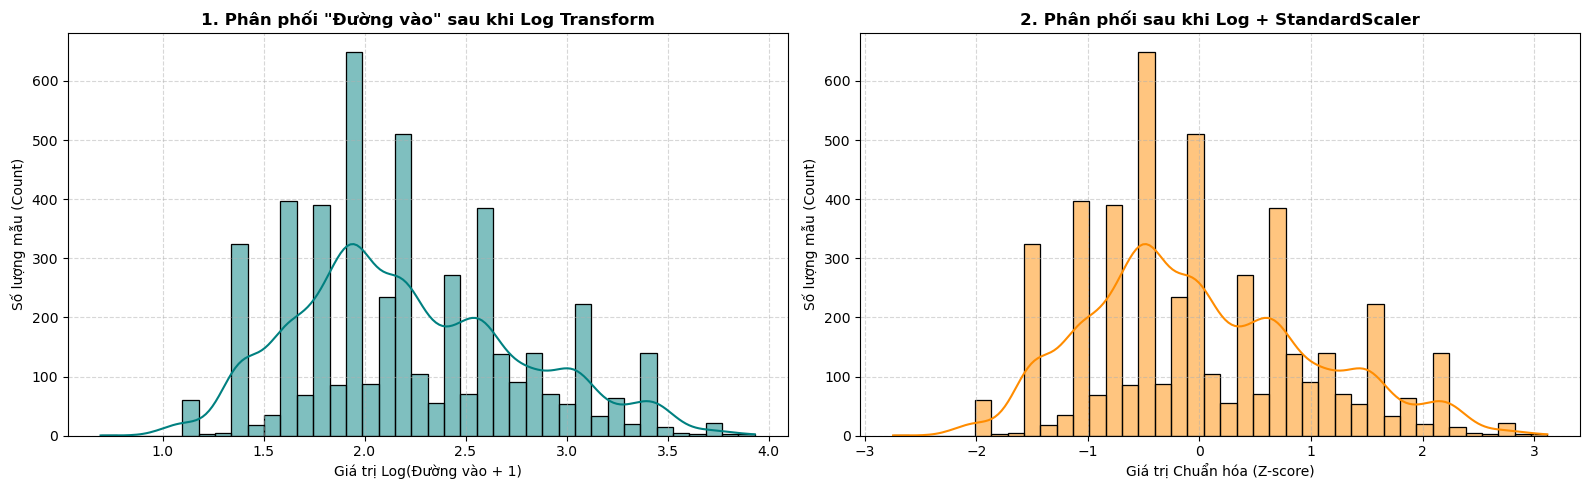

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Trích xuất một bản sao của cột Diện tích để thử nghiệm
dien_tich_test = X_train['Đường vào'].copy()

# 2. Áp dụng Logarithm (Dùng log1p để an toàn nếu có giá trị bằng 0)
dien_tich_log = np.log1p(dien_tich_test)

# 3. Áp dụng StandardScaler lên dữ liệu đã Log
# (Cần reshape(-1, 1) vì StandardScaler yêu cầu mảng 2 chiều)
scaler_test = StandardScaler()
dien_tich_scaled = scaler_test.fit_transform(dien_tich_log.values.reshape(-1, 1)).flatten()

# 4. Vẽ biểu đồ so sánh kết quả từng bước xử lý
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị bước 1: Sau khi Log
sns.histplot(dien_tich_log, kde=True, ax=axes[0], color='teal', bins=40)
axes[0].set_title('1. Phân phối "Đường vào" sau khi Log Transform', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá trị Log(Đường vào + 1)')
axes[0].set_ylabel('Số lượng mẫu (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Đồ thị bước 2: Sau khi Log + Scale
sns.histplot(dien_tich_scaled, kde=True, ax=axes[1], color='darkorange', bins=40)
axes[1].set_title('2. Phân phối sau khi Log + StandardScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Chuẩn hóa (Z-score)')
axes[1].set_ylabel('Số lượng mẫu (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Phương pháp 2: Sử dung phương pháp RobustScaler

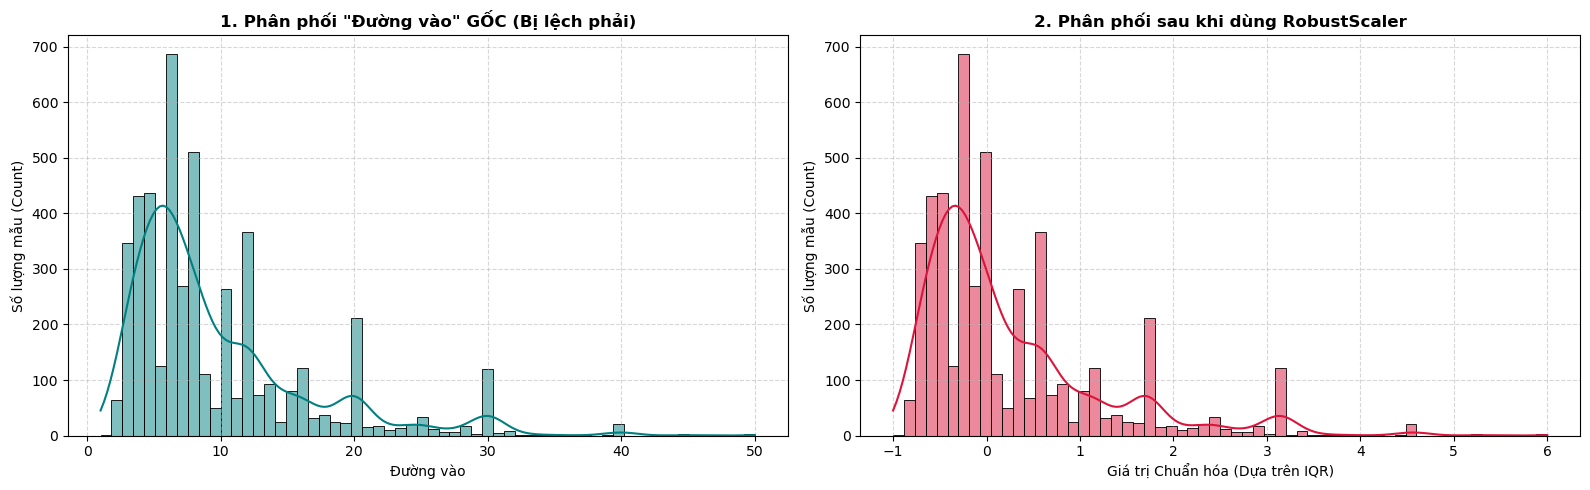

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# 1. Trích xuất một bản sao của cột ĐƯỜNG VÀO để thử nghiệm
duong_vao_test = X_train['Đường vào'].copy()

# 2. Áp dụng RobustScaler
scaler_robust_test = RobustScaler()
duong_vao_robust = scaler_robust_test.fit_transform(duong_vao_test.values.reshape(-1, 1)).flatten()

# 3. Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị bước 1: Phân phối gốc
sns.histplot(duong_vao_test, kde=True, ax=axes[0], color='teal', bins=60)
axes[0].set_title('1. Phân phối "Đường vào" GỐC (Bị lệch phải)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Đường vào')
axes[0].set_ylabel('Số lượng mẫu (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Đồ thị bước 2: Sau khi dùng RobustScaler
sns.histplot(duong_vao_robust, kde=True, ax=axes[1], color='crimson', bins=60)
axes[1].set_title('2. Phân phối sau khi dùng RobustScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Chuẩn hóa (Dựa trên IQR)')
axes[1].set_ylabel('Số lượng mẫu (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Lựa chọn phương pháp

🚀 Đang áp dụng Phương pháp 1: Logarithm + StandardScaler...
✅ Hoàn tất áp dụng Log + StandardScaler cho cả X_train và X_test!


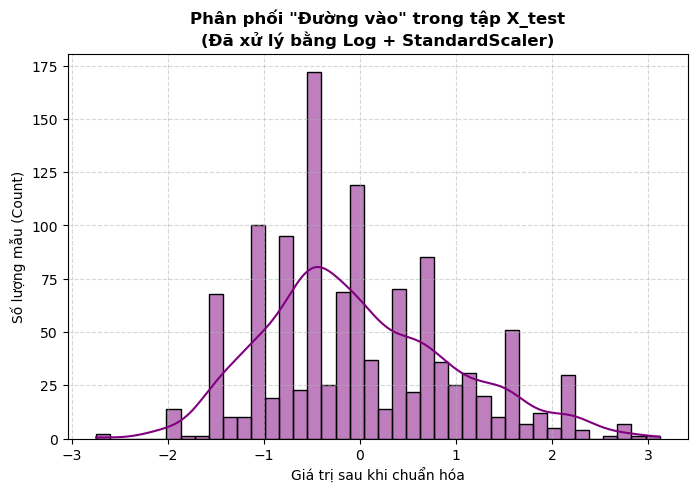

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler

# =================================================================
# ⚙️ BẢNG ĐIỀU KHIỂN: HÃY CHỌN PHƯƠNG PHÁP BẠN MUỐN ÁP DỤNG
# Điền 1 -> Sử dụng (Log1p + StandardScaler)
# Điền 2 -> Sử dụng (RobustScaler)
# =================================================================
PHUONG_PHAP = 1  # <-- Sửa số này thành 1 hoặc 2 tùy ý bạn

if PHUONG_PHAP == 1:
    print("🚀 Đang áp dụng Phương pháp 1: Logarithm + StandardScaler...")
    # Xử lý Log cho cả Train và Test
    X_train['Đường vào'] = np.log1p(X_train['Đường vào'])
    X_test['Đường vào'] = np.log1p(X_test['Đường vào'])
    
    # Chuẩn hóa StandardScaler
    scaler = StandardScaler()
    X_train['Đường vào'] = scaler.fit_transform(X_train[['Đường vào']])
    X_test['Đường vào'] = scaler.transform(X_test[['Đường vào']])
    method_name = "Log + StandardScaler"

elif PHUONG_PHAP == 2:
    print("🚀 Đang áp dụng Phương pháp 2: RobustScaler...")
    # Chuẩn hóa RobustScaler
    scaler = RobustScaler()
    X_train['Đường vào'] = scaler.fit_transform(X_train[['Đường vào']])
    X_test['Đường vào'] = scaler.transform(X_test[['Đường vào']])
    method_name = "RobustScaler"

else:
    print("❌ Lựa chọn không hợp lệ. Vui lòng chọn 1 hoặc 2.")

# =================================================================
# 📊 VẼ BIỂU ĐỒ KIỂM TRA TRÊN TẬP TEST
# =================================================================
if PHUONG_PHAP in [1, 2]:
    print(f"✅ Hoàn tất áp dụng {method_name} cho cả X_train và X_test!")
    
    plt.figure(figsize=(8, 5))
    sns.histplot(X_test['Đường vào'], kde=True, color='purple', bins=40)
    plt.title(f'Phân phối "Đường vào" trong tập X_test\n(Đã xử lý bằng {method_name})', fontsize=12, fontweight='bold')
    plt.xlabel('Giá trị sau khi chuẩn hóa')
    plt.ylabel('Số lượng mẫu (Count)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

## 2.3 Chuẩn hoá 'Tổng số phòng'

### Phương pháp 1: Sử dụng Log và Standardizatiuon

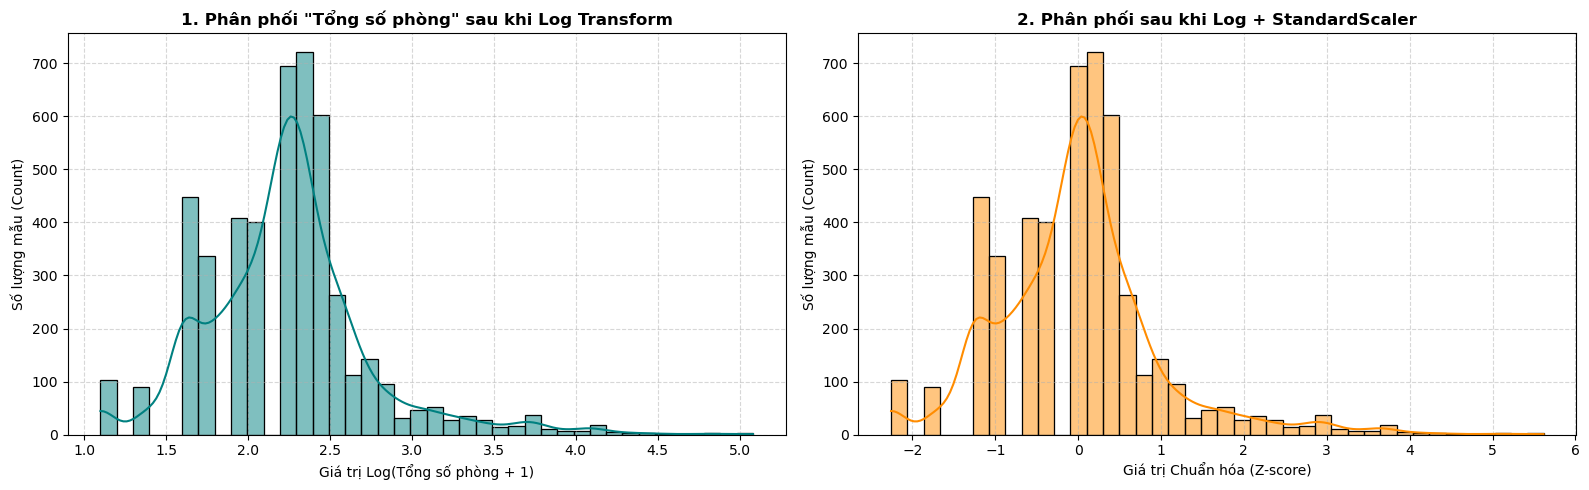

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Trích xuất một bản sao của cột Diện tích để thử nghiệm
Tong_so_phong_test = X_train['Tổng số phòng'].copy()

# 2. Áp dụng Logarithm (Dùng log1p để an toàn nếu có giá trị bằng 0)
Tong_so_phong_log = np.log1p(Tong_so_phong_test)

# 3. Áp dụng StandardScaler lên dữ liệu đã Log
# (Cần reshape(-1, 1) vì StandardScaler yêu cầu mảng 2 chiều)
scaler_test = StandardScaler()
Tong_so_phong_scaled = scaler_test.fit_transform(Tong_so_phong_log.values.reshape(-1, 1)).flatten()

# 4. Vẽ biểu đồ so sánh kết quả từng bước xử lý
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị bước 1: Sau khi Log
sns.histplot(Tong_so_phong_log, kde=True, ax=axes[0], color='teal', bins=40)
axes[0].set_title('1. Phân phối "Tổng số phòng" sau khi Log Transform', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá trị Log(Tổng số phòng + 1)')
axes[0].set_ylabel('Số lượng mẫu (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Đồ thị bước 2: Sau khi Log + Scale
sns.histplot(Tong_so_phong_scaled, kde=True, ax=axes[1], color='darkorange', bins=40)
axes[1].set_title('2. Phân phối sau khi Log + StandardScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Chuẩn hóa (Z-score)')
axes[1].set_ylabel('Số lượng mẫu (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Phương pháp 2: Sử dung phương pháp RobustScaler

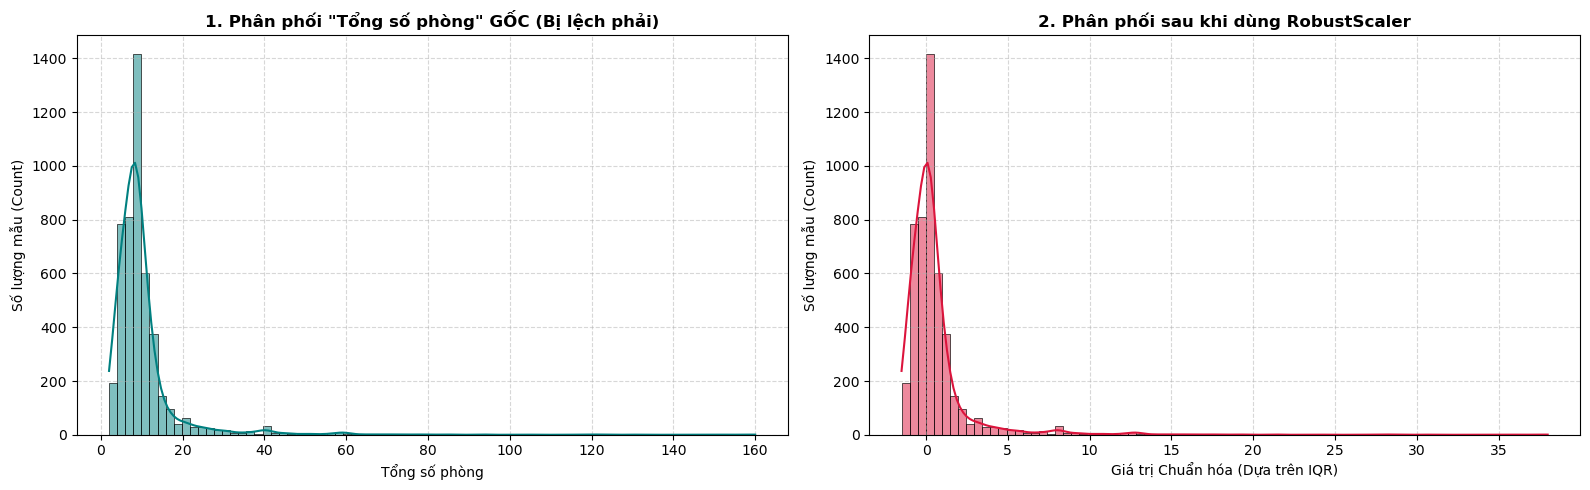

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# 1. Trích xuất một bản sao của cột TỔNG SỐ PHÒNG để thử nghiệm
Tong_so_phong_test = X_train['Tổng số phòng'].copy()

# 2. Áp dụng RobustScaler
scaler_robust_test = RobustScaler()
Tong_so_phong_robust = scaler_robust_test.fit_transform(Tong_so_phong_test.values.reshape(-1, 1)).flatten()

# 3. Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị bước 1: Phân phối gốc
sns.histplot(Tong_so_phong_test, kde=True, ax=axes[0], color='teal', bins=80)
axes[0].set_title('1. Phân phối "Tổng số phòng" GỐC (Bị lệch phải)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tổng số phòng')
axes[0].set_ylabel('Số lượng mẫu (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Đồ thị bước 2: Sau khi dùng RobustScaler
sns.histplot(Tong_so_phong_robust, kde=True, ax=axes[1], color='crimson', bins=80)
axes[1].set_title('2. Phân phối sau khi dùng RobustScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Chuẩn hóa (Dựa trên IQR)')
axes[1].set_ylabel('Số lượng mẫu (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Lựa chọn phương pháp

🚀 Đang áp dụng Phương pháp 1: Logarithm + StandardScaler...
✅ Hoàn tất áp dụng Log + StandardScaler cho cả X_train và X_test!


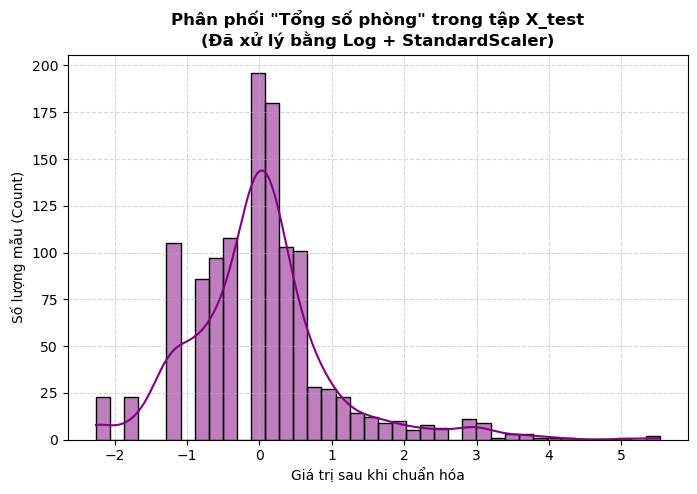

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler

# =================================================================
# ⚙️ BẢNG ĐIỀU KHIỂN: HÃY CHỌN PHƯƠNG PHÁP BẠN MUỐN ÁP DỤNG
# Điền 1 -> Sử dụng (Log1p + StandardScaler)
# Điền 2 -> Sử dụng (RobustScaler)
# =================================================================
PHUONG_PHAP = 1  # <-- Sửa số này thành 1 hoặc 2 tùy ý bạn

if PHUONG_PHAP == 1:
    print("🚀 Đang áp dụng Phương pháp 1: Logarithm + StandardScaler...")
    # Xử lý Log cho cả Train và Test
    X_train['Tổng số phòng'] = np.log1p(X_train['Tổng số phòng'])
    X_test['Tổng số phòng'] = np.log1p(X_test['Tổng số phòng'])
    
    # Chuẩn hóa StandardScaler
    scaler = StandardScaler()
    X_train['Tổng số phòng'] = scaler.fit_transform(X_train[['Tổng số phòng']])
    X_test['Tổng số phòng'] = scaler.transform(X_test[['Tổng số phòng']])
    method_name = "Log + StandardScaler"

elif PHUONG_PHAP == 2:
    print("🚀 Đang áp dụng Phương pháp 2: RobustScaler...")
    # Chuẩn hóa RobustScaler
    scaler = RobustScaler()
    X_train['Tổng số phòng'] = scaler.fit_transform(X_train[['Tổng số phòng']])
    X_test['Tổng số phòng'] = scaler.transform(X_test[['Tổng số phòng']])
    method_name = "RobustScaler"

else:
    print("❌ Lựa chọn không hợp lệ. Vui lòng chọn 1 hoặc 2.")

# =================================================================
# 📊 VẼ BIỂU ĐỒ KIỂM TRA TRÊN TẬP TEST
# =================================================================
if PHUONG_PHAP in [1, 2]:
    print(f"✅ Hoàn tất áp dụng {method_name} cho cả X_train và X_test!")
    
    plt.figure(figsize=(8, 5))
    sns.histplot(X_test['Tổng số phòng'], kde=True, color='purple', bins=40)
    plt.title(f'Phân phối "Tổng số phòng" trong tập X_test\n(Đã xử lý bằng {method_name})', fontsize=12, fontweight='bold')
    plt.xlabel('Giá trị sau khi chuẩn hóa')
    plt.ylabel('Số lượng mẫu (Count)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

## 2.4 Chuẩn hoá 'Số tâng'

Đặc trưng só tầng có 2 đỉnh. có tầm giá trị khá nhỏ (chủ yếu từ 1 đến 6 tầng, tối đa 14 tầng). Bạn có thể dùng MinMaxScaler để đưa toàn bộ về khoảng cố định [0, 1]. Cách này giữ nguyên được tỷ lệ khoảng cách tuyến tính giữa các tầng mà không bị bóp méo bởi Mean.

### Phương pháp 1: Sử dụng StandardScaler

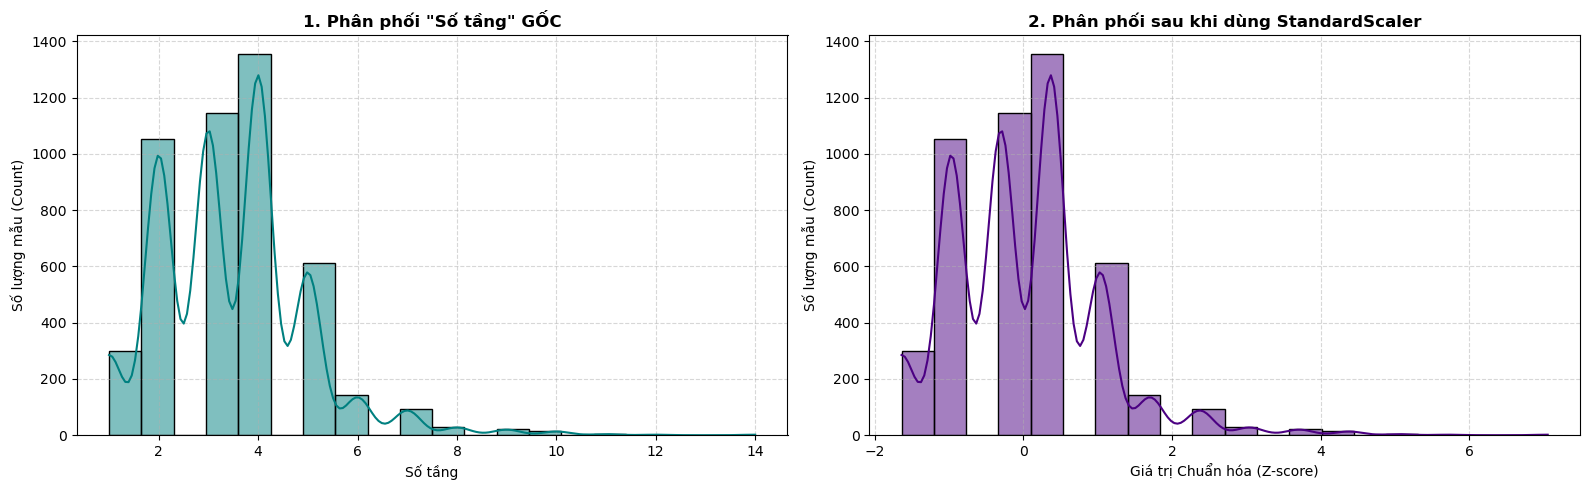

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Tạo bản sao dữ liệu cột Số tầng để chạy thử
so_tang_test = X_train['Số tầng'].copy()

# 2. Áp dụng StandardScaler
scaler_std_test = StandardScaler()
so_tang_std = scaler_std_test.fit_transform(so_tang_test.values.reshape(-1, 1)).flatten()

# 3. Vẽ biểu đồ so sánh dữ liệu Gốc và sau khi Standard Scale
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị gốc
sns.histplot(so_tang_test, kde=True, ax=axes[0], color='teal', bins=20)
axes[0].set_title('1. Phân phối "Số tầng" GỐC', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số tầng')
axes[0].set_ylabel('Số lượng mẫu (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Đồ thị sau Standard Scaler
sns.histplot(so_tang_std, kde=True, ax=axes[1], color='indigo', bins=20)
axes[1].set_title('2. Phân phối sau khi dùng StandardScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Chuẩn hóa (Z-score)')
axes[1].set_ylabel('Số lượng mẫu (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Phương pháp 2: Sử dụng MinMaxScaler

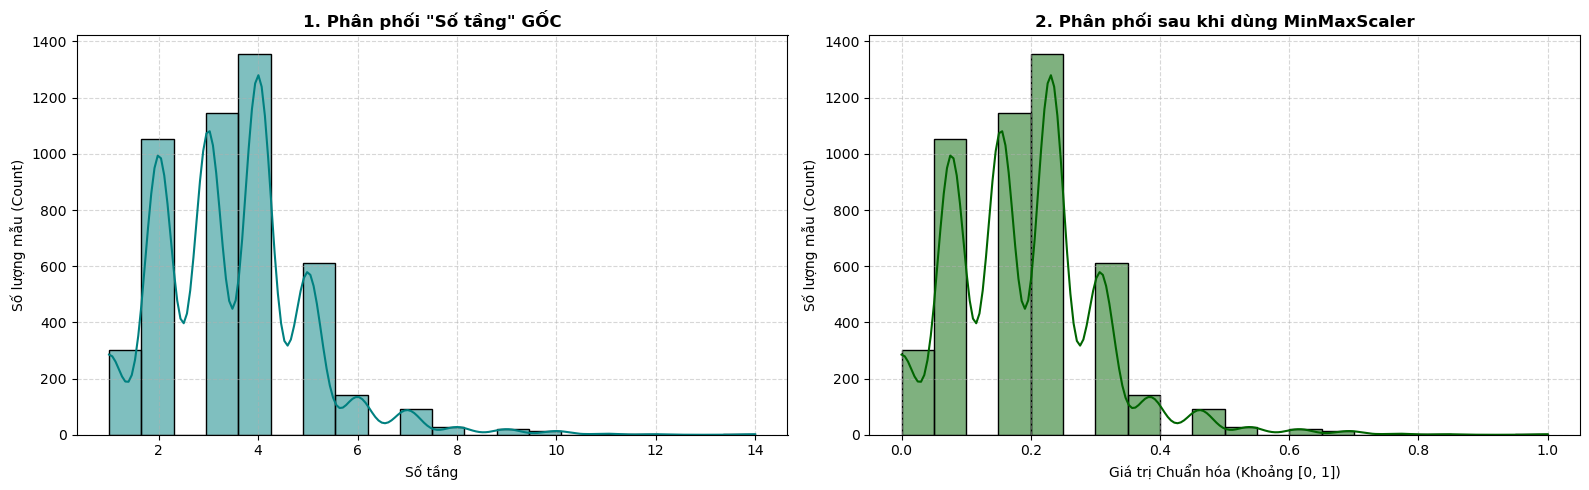

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 1. Tạo bản sao dữ liệu cột Số tầng để chạy thử
so_tang_test = X_train['Số tầng'].copy()

# 2. Áp dụng MinMaxScaler
scaler_minmax_test = MinMaxScaler()
so_tang_minmax = scaler_minmax_test.fit_transform(so_tang_test.values.reshape(-1, 1)).flatten()

# 3. Vẽ biểu đồ so sánh dữ liệu Gốc và sau khi MinMax Scale
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị gốc
sns.histplot(so_tang_test, kde=True, ax=axes[0], color='teal', bins=20)
axes[0].set_title('1. Phân phối "Số tầng" GỐC', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số tầng')
axes[0].set_ylabel('Số lượng mẫu (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Đồ thị sau MinMax Scaler
sns.histplot(so_tang_minmax, kde=True, ax=axes[1], color='darkgreen', bins=20)
axes[1].set_title('2. Phân phối sau khi dùng MinMaxScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Chuẩn hóa (Khoảng [0, 1])')
axes[1].set_ylabel('Số lượng mẫu (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Lựa chọn phương pháp

đặc điểm chung của cả hai phương pháp này là không làm thay đổi hình dáng phân phối gốc

🚀 Đang áp dụng chính thức: MinMaxScaler lên cột Số tầng...
✅ Hoàn tất áp dụng MinMaxScaler cho cả X_train và X_test!


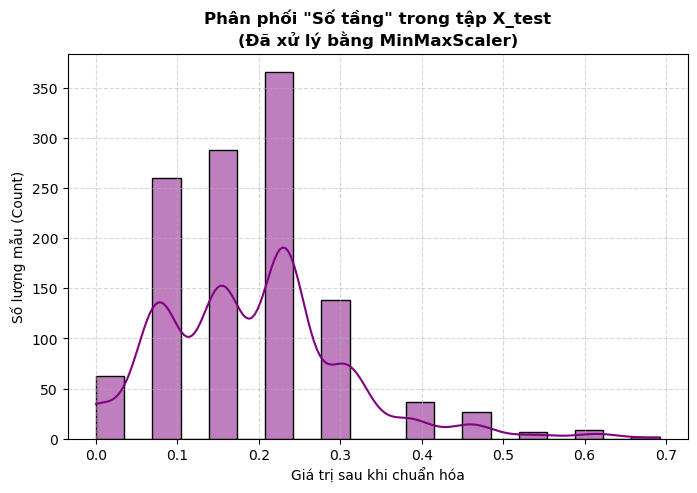

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# =================================================================
# ⚙️ BẢNG ĐIỀU KHIỂN: HÃY CHỌN PHƯƠNG PHÁP BẠN MUỐN ÁP DỤNG
# Điền 1 -> Sử dụng StandardScaler
# Điền 2 -> Sử dụng MinMaxScaler (Khuyên dùng cho Số tầng)
# =================================================================
CHON_PHUONG_PHAP = 2 
if CHON_PHUONG_PHAP == 1:
    print("🚀 Đang áp dụng chính thức: StandardScaler lên cột Số tầng...")
    scaler_tang = StandardScaler()
    X_train['Số tầng'] = scaler_tang.fit_transform(X_train[['Số tầng']])
    X_test['Số tầng'] = scaler_tang.transform(X_test[['Số tầng']])
    method_title = "StandardScaler"

elif CHON_PHUONG_PHAP == 2:
    print("🚀 Đang áp dụng chính thức: MinMaxScaler lên cột Số tầng...")
    scaler_tang = MinMaxScaler()
    X_train['Số tầng'] = scaler_tang.fit_transform(X_train[['Số tầng']])
    X_test['Số tầng'] = scaler_tang.transform(X_test[['Số tầng']])
    method_title = "MinMaxScaler"

else:
    print("❌ Lựa chọn không hợp lệ. Vui lòng chỉ chọn số 1 hoặc 2.")

# =================================================================
# 📊 VẼ BIỂU ĐỒ KIỂM TRA PHÂN PHỐI TRÊN TẬP TEST (X_test)
# =================================================================
if CHON_PHUONG_PHAP in [1, 2]:
    print(f"✅ Hoàn tất áp dụng {method_title} cho cả X_train và X_test!")
    
    plt.figure(figsize=(8, 5))
    sns.histplot(X_test['Số tầng'], kde=True, color='purple', bins=20)
    plt.title(f'Phân phối "Số tầng" trong tập X_test\n(Đã xử lý bằng {method_title})', fontsize=12, fontweight='bold')
    plt.xlabel('Giá trị sau khi chuẩn hóa')
    plt.ylabel('Số lượng mẫu (Count)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

🚀 Đang áp dụng chính thức: MinMaxScaler lên cột Số tầng...
✅ Hoàn tất áp dụng MinMaxScaler cho cả X_train và X_test!


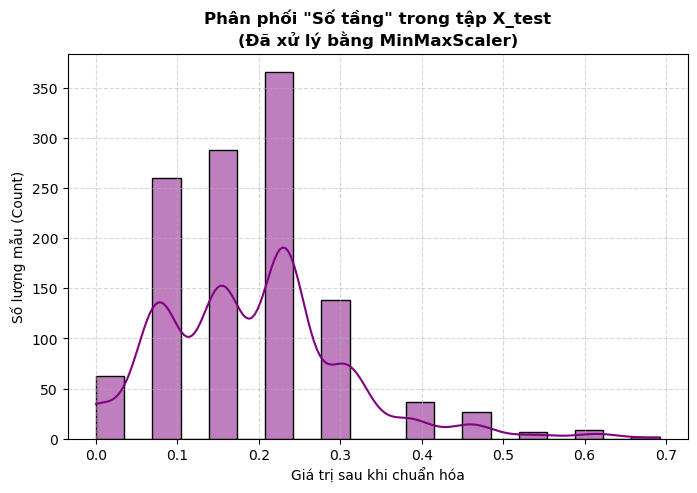

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# =================================================================
# ⚙️ BẢNG ĐIỀU KHIỂN: HÃY CHỌN PHƯƠNG PHÁP BẠN MUỐN ÁP DỤNG
# Điền 1 -> Sử dụng StandardScaler
# Điền 2 -> Sử dụng MinMaxScaler (Khuyên dùng cho Số tầng)
# =================================================================
CHON_PHUONG_PHAP = 2 
if CHON_PHUONG_PHAP == 1:
    print("🚀 Đang áp dụng chính thức: StandardScaler lên cột Số tầng...")
    scaler_tang = StandardScaler()
    X_train['Số tầng'] = scaler_tang.fit_transform(X_train[['Số tầng']])
    X_test['Số tầng'] = scaler_tang.transform(X_test[['Số tầng']])
    method_title = "StandardScaler"

elif CHON_PHUONG_PHAP == 2:
    print("🚀 Đang áp dụng chính thức: MinMaxScaler lên cột Số tầng...")
    scaler_tang = MinMaxScaler()
    X_train['Số tầng'] = scaler_tang.fit_transform(X_train[['Số tầng']])
    X_test['Số tầng'] = scaler_tang.transform(X_test[['Số tầng']])
    method_title = "MinMaxScaler"

else:
    print("❌ Lựa chọn không hợp lệ. Vui lòng chỉ chọn số 1 hoặc 2.")

# =================================================================
# 📊 VẼ BIỂU ĐỒ KIỂM TRA PHÂN PHỐI TRÊN TẬP TEST (X_test)
# =================================================================
if CHON_PHUONG_PHAP in [1, 2]:
    print(f"✅ Hoàn tất áp dụng {method_title} cho cả X_train và X_test!")
    
    plt.figure(figsize=(8, 5))
    sns.histplot(X_test['Số tầng'], kde=True, color='purple', bins=20)
    plt.title(f'Phân phối "Số tầng" trong tập X_test\n(Đã xử lý bằng {method_title})', fontsize=12, fontweight='bold')
    plt.xlabel('Giá trị sau khi chuẩn hóa')
    plt.ylabel('Số lượng mẫu (Count)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

## 2.5 Chuẩn hoá biến mục tiêu bằng Log Transform

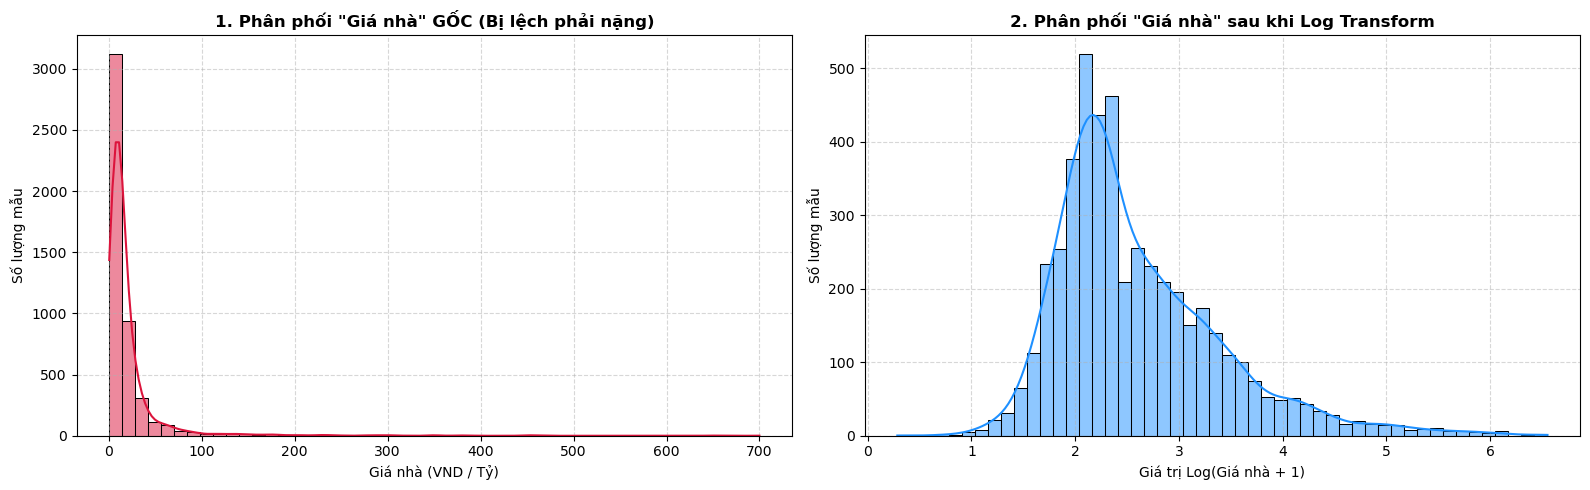

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Áp dụng thử Logarithm lên Giá nhà
y_train_log = np.log1p(y_train)

# 2. Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị 1: Giá nhà GỐC
sns.histplot(y_train, kde=True, ax=axes[0], color='crimson', bins=50)
axes[0].set_title('1. Phân phối "Giá nhà" GỐC (Bị lệch phải nặng)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá nhà (VND / Tỷ)') # Tùy thuộc vào đơn vị gốc của bạn
axes[0].set_ylabel('Số lượng mẫu')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Đồ thị 2: Giá nhà sau khi Log
sns.histplot(y_train_log, kde=True, ax=axes[1], color='dodgerblue', bins=50)
axes[1].set_title('2. Phân phối "Giá nhà" sau khi Log Transform', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Log(Giá nhà + 1)')
axes[1].set_ylabel('Số lượng mẫu')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Khi evaluate, y_pred sẽ ở dạng log. Trước khi tính toán độ đo phỉ đổi ngược về giá trị thực.

In [66]:
# ═══════════════════════════════════════════════════════════════════════
# CELL LƯU FILE 3: DỮ LIỆU DÀNH CHO MÔ HÌNH HỒI QUY / TUYẾN TÍNH
# ═══════════════════════════════════════════════════════════════════════
import numpy as np

# 1. Áp dụng chính thức Log1p cho biến mục tiêu target (y)
y_train_log = np.log1p(y_train)
if 'y_test' in locals():
    y_test_log = np.log1p(y_test)

# 2. Lấy X_train và X_test hiện tại (Lúc này đã được mã hóa + Scale hoàn chỉnh ở các cell trên)
X_train_linear = X_train.copy()
X_test_linear = X_test.copy()

# 3. Ghép đặc trưng đã scale hoàn chỉnh và target đã log transform
df_train_linear = pd.concat([X_train_linear, y_train_log], axis=1)
if 'y_test' in locals():
    df_test_linear = pd.concat([X_test_linear, y_test_log], axis=1)
else:
    df_test_linear = X_test_linear.copy()

# 4. Xuất file mã hóa hoàn chỉnh cuối cùng
df_train_linear.to_csv('data_output/3_data_preprocessed_linear_train.csv', index=False)
df_test_linear.to_csv('data_output/3_data_preprocessed_linear_test.csv', index=False)

print("💾 FILE 3: Đã lưu dữ liệu chuẩn hóa hoàn chỉnh cho mô hình Tuyến tính thành công!")
print("   (Lưu ý: Biến mục tiêu 'y' trong file này đã được chuyển đổi sang Log1p)")
print("   -> data_output/3_data_preprocessed_linear_train.csv")
print("   -> data_output/3_data_preprocessed_linear_test.csv")

💾 FILE 3: Đã lưu dữ liệu chuẩn hóa hoàn chỉnh cho mô hình Tuyến tính thành công!
   (Lưu ý: Biến mục tiêu 'y' trong file này đã được chuyển đổi sang Log1p)
   -> data_output/3_data_preprocessed_linear_train.csv
   -> data_output/3_data_preprocessed_linear_test.csv
